##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
# Provide your solution here
!pip install torch torchvision transformers scikit-learn pillow -q

In [3]:
import torch
import numpy as np
from torchvision.datasets import OxfordIIITPet
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
device = "cuda" if torch.cuda.is_available() else "cpu"

dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True
)

model_name = "facebook/dinov2-small"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

100%|██████████| 792M/792M [00:28<00:00, 27.9MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 14.3MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((384,), eps=1e-06,

In [4]:
cat_indices = []
dog_indices = []

for i in range(len(dataset)):
    image, label = dataset[i]

    if label <= 11 and len(cat_indices) < 10:
        cat_indices.append(i)

    elif label >= 12 and len(dog_indices) < 10:
        dog_indices.append(i)

    if len(cat_indices) == 10 and len(dog_indices) == 10:
        break

selected_indices = cat_indices + dog_indices

true_labels = [0] * 10 + [1] * 10

print("Cat images selected:", len(cat_indices))
print("Dog images selected:", len(dog_indices))
print("Total images selected:", len(selected_indices))
features = []

for count, idx in enumerate(selected_indices):
    print(f"Processing image {count + 1}/20")

    image, original_label = dataset[idx]
    image = image.convert("RGB")

    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    cls_token = outputs.last_hidden_state[:, 0, :]
    features.append(cls_token.squeeze().cpu().numpy())

features = np.array(features)

print("Feature shape:", features.shape)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

predicted_clusters = kmeans.fit_predict(features)

print("Predicted clusters:")
print(predicted_clusters)

print("True labels:")
print(true_labels)
acc1 = accuracy_score(true_labels, predicted_clusters)
acc2 = accuracy_score(true_labels, 1 - predicted_clusters)

best_accuracy = max(acc1, acc2)

print("Best clustering accuracy:", best_accuracy)

print("Confusion matrix:")
print(confusion_matrix(true_labels, predicted_clusters))
for i, idx in enumerate(selected_indices):
    image, original_label = dataset[idx]

    actual = "Cat" if true_labels[i] == 0 else "Dog"
    cluster = predicted_clusters[i]

    print(f"Image {i+1}: Actual = {actual}, Cluster = {cluster}")

Cat images selected: 10
Dog images selected: 10
Total images selected: 20
Processing image 1/20
Processing image 2/20
Processing image 3/20
Processing image 4/20
Processing image 5/20
Processing image 6/20
Processing image 7/20
Processing image 8/20
Processing image 9/20
Processing image 10/20
Processing image 11/20
Processing image 12/20
Processing image 13/20
Processing image 14/20
Processing image 15/20
Processing image 16/20
Processing image 17/20
Processing image 18/20
Processing image 19/20
Processing image 20/20
Feature shape: (20, 384)
Predicted clusters:
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
True labels:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Best clustering accuracy: 1.0
Confusion matrix:
[[10  0]
 [ 0 10]]
Image 1: Actual = Cat, Cluster = 0
Image 2: Actual = Cat, Cluster = 0
Image 3: Actual = Cat, Cluster = 0
Image 4: Actual = Cat, Cluster = 0
Image 5: Actual = Cat, Cluster = 0
Image 6: Actual = Cat, Cluster = 0
Image 7: Actual = Cat, Cluster = 0
Im

In [5]:
!pip install matplotlib seaborn -q

Clustering Accuracy: 100.00%


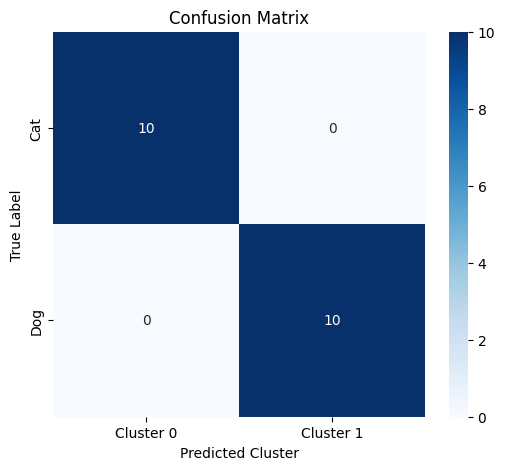

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


print(f"Clustering Accuracy: {best_accuracy * 100:.2f}%")


cm = confusion_matrix(true_labels, predicted_clusters)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cluster 0", "Cluster 1"],
    yticklabels=["Cat", "Dog"]
)

plt.xlabel("Predicted Cluster")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [8]:
# Provide your solution here
!pip install torch transformers pillow matplotlib requests -q
import torch
import requests
import matplotlib.pyplot as plt

from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "facebook/dinov2-small-imagenet1k-1-layer"
processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModelForImageClassification.from_pretrained(model_id).to(device)
model.eval()


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

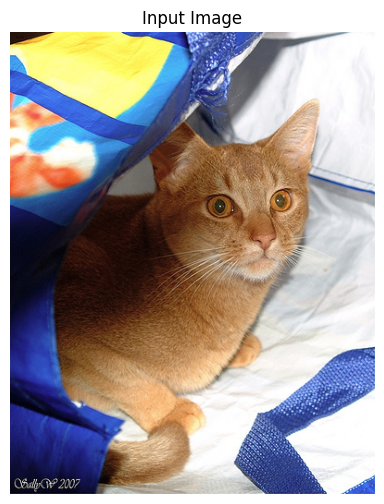

In [12]:
image, label = dataset[0]
image = image.convert("RGB")
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [14]:
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)
logits = outputs.logits
predicted_class_id = logits.argmax(-1).item()

predicted_label = model.config.id2label[predicted_class_id]

print("Predicted Class ID:", predicted_class_id)
print("Predicted Label:", predicted_label)
probabilities = torch.nn.functional.softmax(logits, dim=-1)

top5 = torch.topk(probabilities, 5)

print("Top 5 Predictions:\n")

for score, idx in zip(top5.values[0], top5.indices[0]):

    label = model.config.id2label[idx.item()]

    print(f"{label}: {score.item() * 100:.2f}%")

Predicted Class ID: 750
Predicted Label: quilt, comforter, comfort, puff
Top 5 Predictions:

quilt, comforter, comfort, puff: 14.73%
Egyptian cat: 11.54%
bath towel: 9.47%
sleeping bag: 6.61%
bucket, pail: 4.60%
